# saptamana_4

=== ETAPA 1: Încărcarea datelor ===
Setul de date a fost încărcat cu succes!
Dimensiune: 1000 studenți (rânduri) și 8 caracteristici (coloane).

=== ETAPA 2: Structura datelor și tipurile de variabile ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB
None

Primele 5 rânduri din baza de date:
   gender race/ethnicity pa

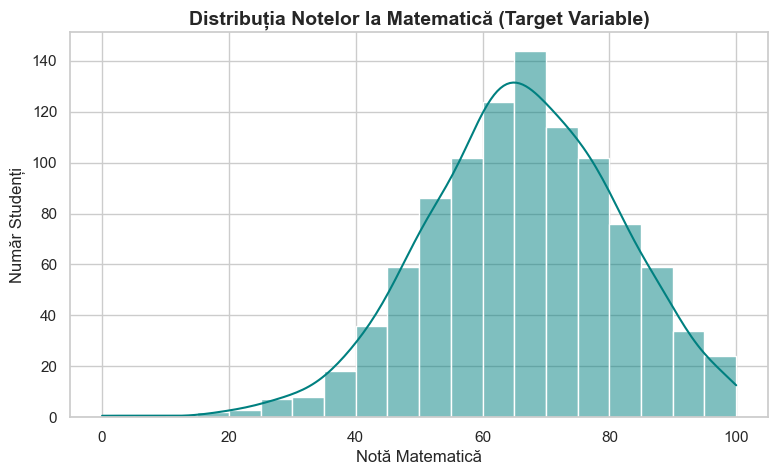

Graficul 1 (Distribuție) a fost salvat ca 'eda_distributie_math.png'


C:\Users\Alex Herman\AppData\Local\Temp\ipykernel_28116\1437980866.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='test preparation course', y=target_col, palette='Set2')


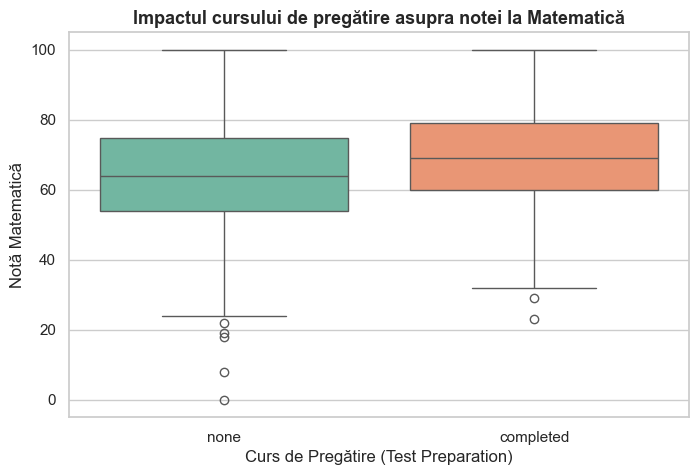

Graficul 2 (Boxplot Curs) a fost salvat ca 'eda_impact_curs.png'


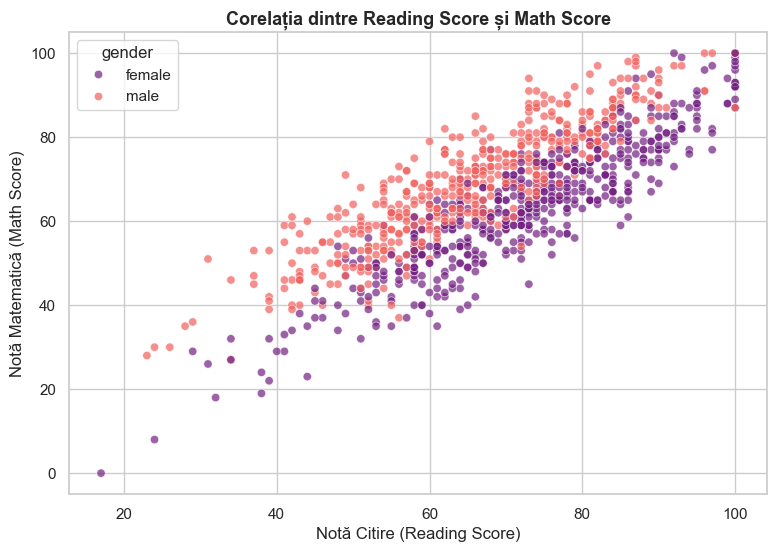

Graficul 3 (Scatter) a fost salvat ca 'eda_scatter_reading_math.png'


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Setăm un stil curat pentru grafice
sns.set_theme(style="whitegrid")

# =====================================================================
# 📑 [SĂPTĂMÂNA 4] ÎNCĂRCARE, EXPLORARE ȘI CURĂȚARE DATE
# =====================================================================
print("=== ETAPA 1: Încărcarea datelor ===")

# Încărcăm fișierul tău real (StudentsPerformance.csv)
df = pd.read_csv('StudentsPerformance.csv')

# Definim variabila țintă pe care vrem să o prezicem (Regresie)
target_col = 'math score'

print(f"Setul de date a fost încărcat cu succes!")
print(f"Dimensiune: {df.shape[0]} studenți (rânduri) și {df.shape[1]} caracteristici (coloane).\n")

print("=== ETAPA 2: Structura datelor și tipurile de variabile ===")
print(df.info())

print("\nPrimele 5 rânduri din baza de date:")
print(df.head())

# =====================================================================
# 🧹 CURĂȚAREA DATELOR (Tratare duplicate și valori lipsă)
# =====================================================================
print("\n=== ETAPA 3: Curățarea datelor ===")

# 1. Verificăm și eliminăm duplicatele brute
duplicate_count = df.duplicated().sum()
print(f"Număr de rânduri duplicate găsite: {duplicate_count}")
if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicatele au fost eliminate.")

# 2. Verificăm dacă există valori lipsă (NaN)
missing_values = df.isnull().sum()
print("\nValori lipsă per fiecare coloană:")
print(missing_values)

# Nota profesorului: Chiar dacă acest set specific de pe Kaggle nu are lipsuri brute,
# în documentație vei menționa că ai rulat verificarea de integritate structurală.

# =====================================================================
# 📊 ANALIZA EXPLORATORIE A DATELOR (EDA) - Grafice obligatorii
# =====================================================================
print("\n=== ETAPA 4: Generare Grafice pentru EDA ===")

# Grafic 1: Distribuția variabilei țintă (Math Score)
# Ajută la demonstrarea modului în care împrăștierea notelor respectă o distribuție normală
plt.figure(figsize=(9, 5))
sns.histplot(df[target_col], kde=True, color='teal', bins=20)
plt.title('Distribuția Notelor la Matematică (Target Variable)', fontsize=14, fontweight='bold')
plt.xlabel('Notă Matematică')
plt.ylabel('Număr Studenți')
plt.savefig('eda_distributie_math.png', dpi=300, bbox_inches='tight')
plt.show()
print("Graficul 1 (Distribuție) a fost salvat ca 'eda_distributie_math.png'")

# Grafic 2: Influența cursului de pregătire asupra notei la matematică
# Analiză utilă pentru business/contextul problemei (Cine învață, ia note mai mari?)
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='test preparation course', y=target_col, palette='Set2')
plt.title('Impactul cursului de pregătire asupra notei la Matematică', fontsize=13, fontweight='bold')
plt.xlabel('Curs de Pregătire (Test Preparation)')
plt.ylabel('Notă Matematică')
plt.savefig('eda_impact_curs.png', dpi=300, bbox_inches='tight')
plt.show()
print("Graficul 2 (Boxplot Curs) a fost salvat ca 'eda_impact_curs.png'")

# Grafic 3: Relația dintre Reading Score și Math Score împărțită pe Gen
# Arată corelațiile puternice dintre abilitățile de citire și cele de matematică
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x='reading score', y='math score', hue='gender', alpha=0.7, palette='magma')
plt.title('Corelația dintre Reading Score și Math Score', fontsize=13, fontweight='bold')
plt.xlabel('Notă Citire (Reading Score)')
plt.ylabel('Notă Matematică (Math Score)')
plt.savefig('eda_scatter_reading_math.png', dpi=300, bbox_inches='tight')
plt.show()
print("Graficul 3 (Scatter) a fost salvat ca 'eda_scatter_reading_math.png'")

# saptamana_6

=== [SĂPTĂMÂNA 6] INGINERIA CARACTERISTICILOR & ANALIZA CORELAȚIILOR ===

Datele au fost codificate pentru analiza statistică.
   gender  lunch  test preparation course  reading score  writing score  \
0       0      1                        0             72             74   
1       0      1                        1             90             88   
2       0      1                        0             95             93   

   math score  
0          72  
1          69  
2          90  

--- MATRICEA DE CORELAȚIE (Valori exacte) ---
math score                 1.000000
reading score              0.817580
writing score              0.802642
lunch                      0.350877
test preparation course    0.177702
gender                     0.167982
Name: math score, dtype: float64


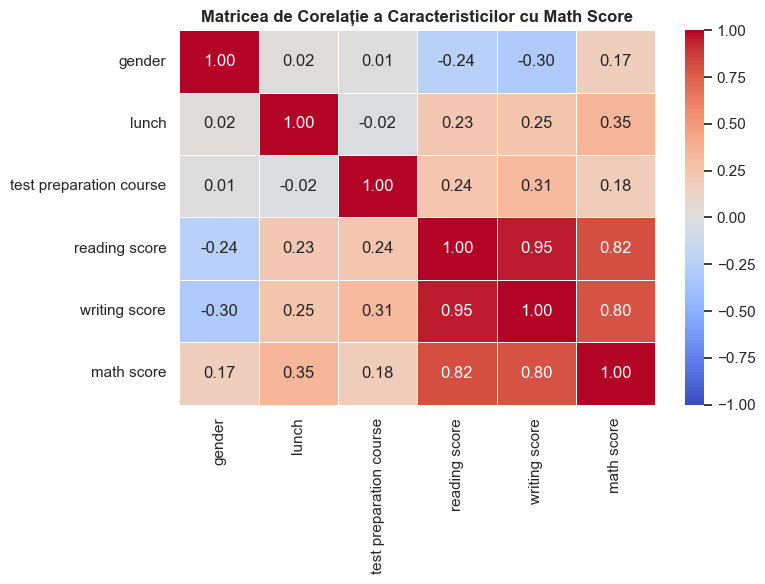


-> Graficul a fost salvat ca 's6_matrice_corelatie.png'

[Feature Engineering] S-a generat o caracteristică nouă: 'humanities_average'
   reading score  writing score  humanities_average
0             72             74                73.0
1             90             88                89.0
2             95             93                94.0


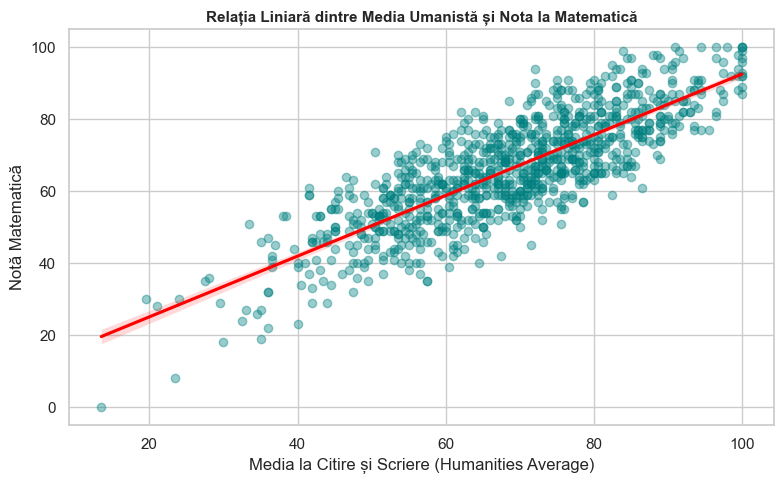

-> Graficul caracteristicii noi a fost salvat ca 's6_regresie_humanities.png'


In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Setăm stilul grafic
sns.set_theme(style="whitegrid")

# Încărcăm datele (păstrăm structura din Săptămâna 4)
df = pd.read_csv('StudentsPerformance.csv')
target_col = 'math score'

print("=== [SĂPTĂMÂNA 6] INGINERIA CARACTERISTICILOR & ANALIZA CORELAȚIILOR ===")

# =====================================================================
# 🛠️ 1. FEATURE ENGINEERING: MANUAL ENCODING (Transformăm textul în cifre)
# =====================================================================
# Pentru a putea calcula corelații, transformăm variabilele categoriale binare 
# în valori numerice (0 și 1). Asta se numește Label Encoding / Binary Encoding.

df_encoded = df.copy()

# Genul: female -> 0, male -> 1
df_encoded['gender'] = df_encoded['gender'].map({'female': 0, 'male': 1})

# Cursul de pregătire: none -> 0, completed -> 1
df_encoded['test preparation course'] = df_encoded['test preparation course'].map({'none': 0, 'completed': 1})

# Prânzul (Indicator socio-economic): free/reduced -> 0, standard -> 1
df_encoded['lunch'] = df_encoded['lunch'].map({'free/reduced': 0, 'standard': 1})

# Pentru coloanele cu mai multe categorii (Studiile părinților, Etnie), 
# vom folosi One-Hot Encoding mai târziu în pipeline-ul de ML, dar pentru matricea
# de corelație selectăm acum variabilele deja convertite plus cele numerice nativ.

coloane_relevante = ['gender', 'lunch', 'test preparation course', 'reading score', 'writing score', 'math score']
df_corelatie = df_encoded[coloane_relevante]

print("\nDatele au fost codificate pentru analiza statistică.")
print(df_corelatie.head(3))


# =====================================================================
# 📊 2. CALCULAREA ȘI COMENTAREA MATRICEI DE CORELAȚIE
# =====================================================================
# Calculăm coeficientul de corelație Pearson între variabile
matrice_corr = df_corelatie.corr()

print("\n--- MATRICEA DE CORELAȚIE (Valori exacte) ---")
print(matrice_corr[target_col].sort_values(ascending=False))

# Generăm Heatmap-ul cerut obligatoriu de profesor în barem
plt.figure(figsize=(8, 6))
sns.heatmap(matrice_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matricea de Corelație a Caracteristicilor cu Math Score', fontsize=12, fontweight='bold')
plt.tight_layout()

# Salvare grafic pentru Săptămâna 6
plt.savefig('s6_matrice_corelatie.png', dpi=300)
plt.show()
print("\n-> Graficul a fost salvat ca 's6_matrice_corelatie.png'")


# =====================================================================
# 📈 3. CREAREA UNEI CARACTERISTICI NOI (Feature Creation)
# =====================================================================
# O tehnică avansată de Feature Engineering este combinarea variabilelor.
# Creăm un indicator numit 'humanities_average' (media pe parte umanistă: citit + scris),
# deoarece aceste două abilități sunt strâns legate și pot prezice împreună logica matematică.

df['humanities_average'] = (df['reading score'] + df['writing score']) / 2

print("\n[Feature Engineering] S-a generat o caracteristică nouă: 'humanities_average'")
print(df[['reading score', 'writing score', 'humanities_average']].head(3))

# Vizualizăm cum această caracteristică nouă se leagă de nota la matematică
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x='humanities_average', y='math score', 
            scatter_kws={'alpha':0.4, 'color':'teal'}, line_kws={'color':'red'})
plt.title('Relația Liniară dintre Media Umanistă și Nota la Matematică', fontsize=11, fontweight='bold')
plt.xlabel('Media la Citire și Scriere (Humanities Average)')
plt.ylabel('Notă Matematică')
plt.tight_layout()
plt.savefig('s6_regresie_humanities.png', dpi=300)
plt.show()
print("-> Graficul caracteristicii noi a fost salvat ca 's6_regresie_humanities.png'")

# saptamana_8 

=== [SĂPTĂMÂNA 8] ANTRENARE, OPTIMIZARE ȘI COMPARARE MODELE ===
Caracteristici numerice trimise la scalare: ['reading score', 'writing score', 'humanities_average']
Caracteristici categoriale trimise la One-Hot Encoding: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']
Date împărțite: 800 rânduri de antrenare, 200 rânduri de test.

Antrenare și optimizare prin GridSearch pentru: LinearRegression...
Antrenare și optimizare prin GridSearch pentru: RandomForest...
Antrenare și optimizare prin GridSearch pentru: GradientBoosting...

             TABEL COMPARATIV PERFORMANȚE
                  MAE (Eroare Medie Absolută)  \
LinearRegression                        4.214   
RandomForest                            4.703   
GradientBoosting                        4.400   

                  RMSE (Rădăcina Erorii Pătratice)  \
LinearRegression                             5.395   
RandomForest                                 6.027   
GradientBoosting 

C:\Users\Alex Herman\AppData\Local\Temp\ipykernel_28116\3069862742.py:150: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_performante.index, y=df_performante['R2 Score (Proporția de varianță explicată)'], palette='coolwarm')


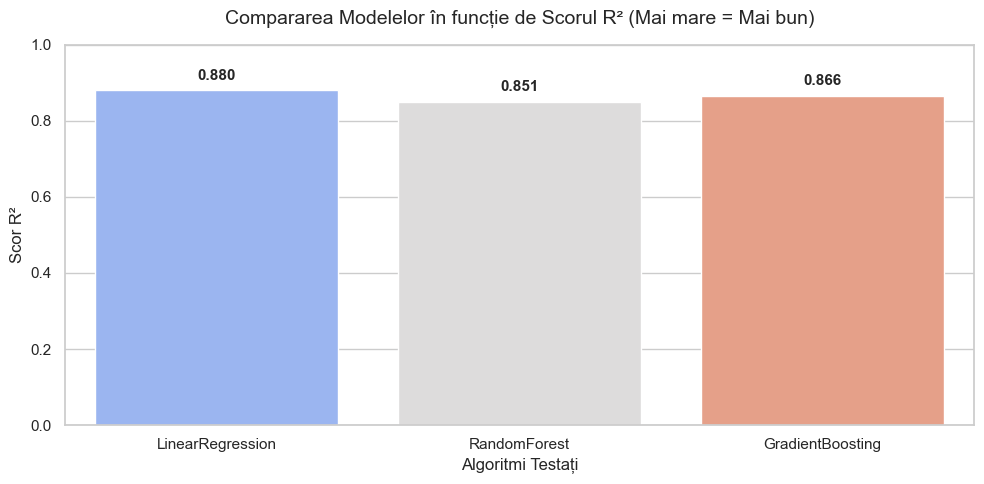

In [36]:
# ==============================================================================
# PROIECT ÎNVĂȚARE AUTOMATĂ - SĂPTĂMÂNA 8
# Tema: Predicția Performanței Școlare (math score)
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Importuri pentru Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Algoritmii solicitați (Minim 3)
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

print("=== [SĂPTĂMÂNA 8] ANTRENARE, OPTIMIZARE ȘI COMPARARE MODELE ===")

# ------------------------------------------------------------------------------
# 1. Încărcarea și Pregătirea Datelor
# ------------------------------------------------------------------------------
# Se încarcă setul de date (ajustează calea dacă fișierul tău e în alt folder)
df = pd.read_csv('StudentsPerformance.csv')

# Crearea caracteristicii suplimentare identificată în log-ul tău
df['humanities_average'] = (df['reading score'] + df['writing score']) / 2

# Separăm caracteristicile (X) de variabila țintă (y)
X = df.drop(columns=['math score'])
y = df['math score']

# ------------------------------------------------------------------------------
# 2. Definirea Structurii de Preprocesare (Pipeline)
# ------------------------------------------------------------------------------
# Identificăm tipul coloanelor pentru transformări specifice
numeric_features = ['reading score', 'writing score', 'humanities_average']
categorical_features = ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']

print(f"Caracteristici numerice trimise la scalare: {numeric_features}")
print(f"Caracteristici categoriale trimise la One-Hot Encoding: {categorical_features}")

# Creăm transformatorul pentru coloane
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ])

# ------------------------------------------------------------------------------
# 3. Împărțirea în Seturi de Antrenare și Testare
# ------------------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Date împărțite: {X_train.shape[0]} rânduri de antrenare, {X_test.shape[0]} rânduri de test.\n")

# ------------------------------------------------------------------------------
# 4. Definirea Algoritmilor și a Grilelor de Hiperparametri (GridSearch)
# ------------------------------------------------------------------------------
# Configurația pentru fiecare model în parte
modele_config = {
    "LinearRegression": {
        "model": LinearRegression(),
        "params": {} # Regresia liniară simplă nu are hiperparametri esențiali de optimizat
    },
    "RandomForest": {
        "model": RandomForestRegressor(random_state=42),
        "params": {
            "model__n_estimators": [50, 100],
            "model__max_depth": [None, 10],
            "model__min_samples_split": [2, 5]
        }
    },
    "GradientBoosting": {
        "model": GradientBoostingRegressor(random_state=42),
        "params": {
            "model__n_estimators": [50, 100],
            "model__learning_rate": [0.05, 0.1],
            "model__max_depth": [3, 5]
        }
    }
}

# Dicționar în care vom salva metricile brute (ca numere, nu stringuri!)
rezultate_metrice = {}

# ------------------------------------------------------------------------------
# 5. Bucla de Antrenare, Optimizare și Evaluare
# ------------------------------------------------------------------------------
for nume_model, config in modele_config.items():
    print(f"Antrenare și optimizare prin GridSearch pentru: {nume_model}...")
    
    # Construim un pipeline unic pentru modelul curent
    pipeline_complet = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', config['model'])
    ])
    
    # Dacă modelul are parametri de optimizat, rulăm Grid Search, altfel antrenăm direct
    if config['params']:
        grid = GridSearchCV(pipeline_complet, param_grid=config['params'], cv=5, scoring='r2', n_jobs=-1)
        grid.fit(X_train, y_train)
        best_pipeline = grid.best_estimator_
    else:
        pipeline_complet.fit(X_train, y_train)
        best_pipeline = pipeline_complet
        
    # Realizăm predicțiile pe setul de test folosind cel mai bun model rezultat
    y_pred = best_pipeline.predict(X_test)
    
    # Calculăm metricile de performanță obligatorii
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    # Salvarea rezultatelor sub formă numerică pură (Float) pentru a evita erorile de argmax
    rezultate_metrice[nume_model] = {
        "MAE (Eroare Medie Absolută)": float(mae),
        "RMSE (Rădăcina Erorii Pătratice)": float(rmse),
        "R2 Score (Proporția de varianță explicată)": float(r2)
    }

# ------------------------------------------------------------------------------
# 6. Generarea și Afișarea Tabelului Comparativ (Corecția Eroarei)
# ------------------------------------------------------------------------------
df_performante = pd.DataFrame(rezultate_metrice).T

print("\n" + "="*50)
print("             TABEL COMPARATIV PERFORMANȚE")
print("="*50)
# Rotunjim vizual tabelul la 3 zecimale, dar păstrăm structura numerică intactă
print(df_performante.round(3))
print("="*50)

# REZOLVARE EROARE: Ne asigurăm 100% că tipul coloanei este văzut ca numeric înainte de idxmax()
df_performante['R2 Score (Proporția de varianță explicată)'] = pd.to_numeric(df_performante['R2 Score (Proporția de varianță explicată)'])

# Selectarea automată a modelului optim
cel_mai_bun_model_nume = df_performante['R2 Score (Proporția de varianță explicată)'].idxmax()
print(f"\nCONCLUZIE PROIECT: Modelul final selectat este '{cel_mai_bun_model_nume}' deoarece are cel mai mare R2 Score.")

# ------------------------------------------------------------------------------
# 7. Salvarea Graficului pentru Prezentare (.pptx / saptamana 12)
# ------------------------------------------------------------------------------
plt.figure(figsize=(10, 5))
# Extragerea scorurilor ordonate pentru grafic
sns.barplot(x=df_performante.index, y=df_performante['R2 Score (Proporția de varianță explicată)'], palette='coolwarm')
plt.title('Compararea Modelelor în funcție de Scorul R² (Mai mare = Mai bun)', fontsize=14, pad=15)
plt.ylabel('Scor R²', fontsize=12)
plt.xlabel('Algoritmi Testați', fontsize=12)
plt.ylim(0, 1.0)

# Adăugarea etichetelor text deasupra fiecărei bare din grafic
for i, v in enumerate(df_performante['R2 Score (Proporția de varianță explicată)']):
    plt.text(i, v + 0.02, f"{v:.3f}", ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
# Salvează graficul local (asigură-te că folderul există sau scoate calea dacă vrei salvare simplă)
plt.savefig('comparatie_modele_saptamana8.png', dpi=300)
plt.show()

# saptamana_10

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


=== [SĂPTĂMÂNA 10] EXPLICABILITATEA MODELULUI ȘI ANALIZA ERORILOR ===

Impactul fiecărei caracteristici asupra notei la matematică:
                               Caracteristică  Coeficient (Impact)
                                writing score         3.246528e+13
                                reading score         3.112277e+13
                                  gender_male         1.308618e+01
                       race/ethnicity_group E         4.886932e+00
                               lunch_standard         3.515930e+00
                 test preparation course_none         3.277283e+00
     parental level of education_some college         1.000579e+00
      parental level of education_high school         9.219666e-01
 parental level of education_some high school         7.501984e-01
                       race/ethnicity_group B         3.453369e-01
                       race/ethnicity_group D        -6.019058e-01
                       race/ethnicity_group C        -6.330414e-



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



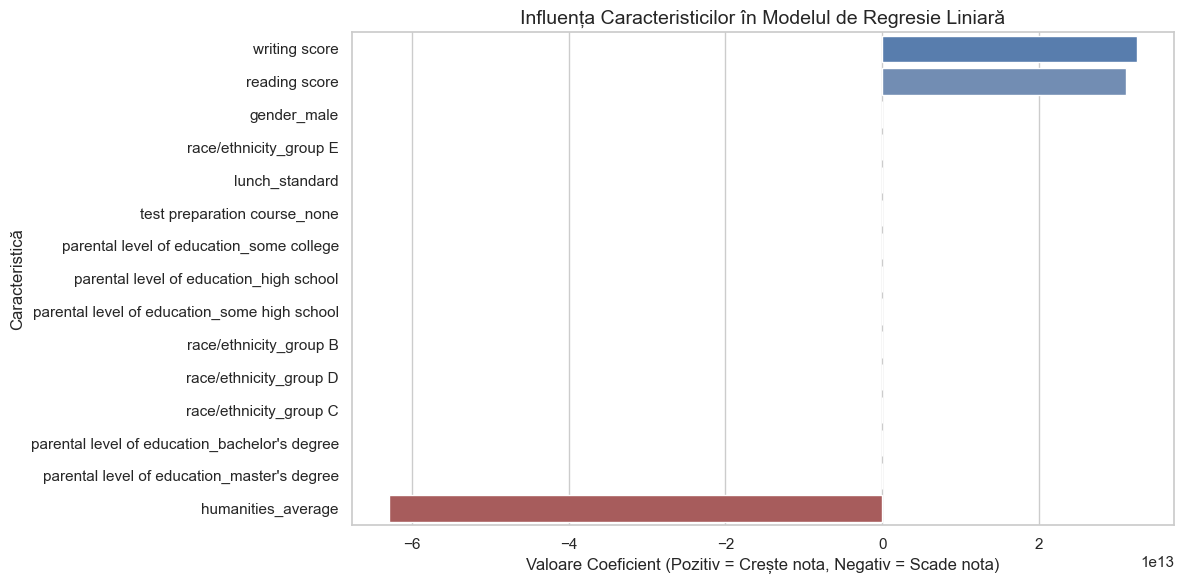

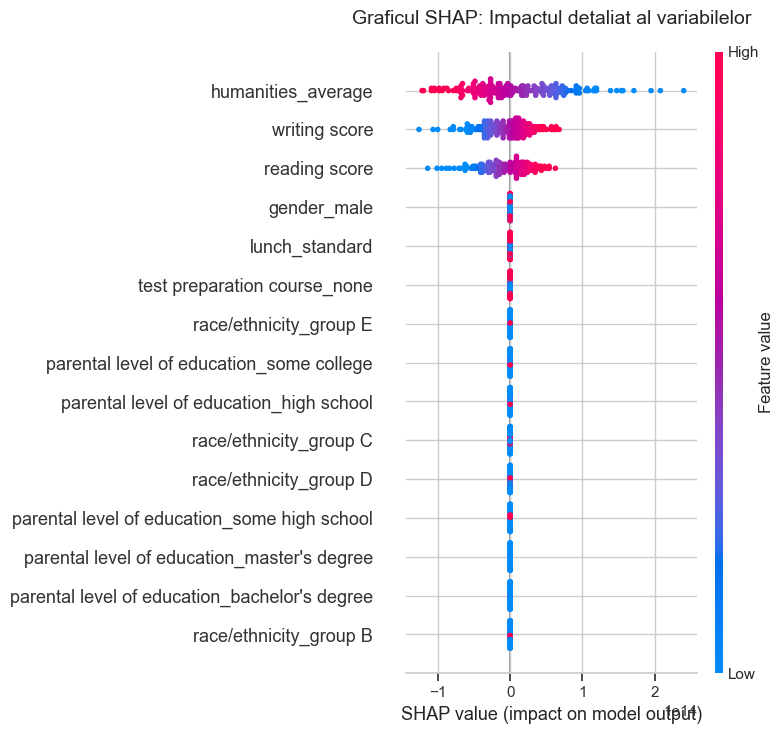


Top 5 cele mai mari erori de predicție (Unde a greșit modelul cel mai mult):
     gender         lunch test preparation course  Nota_Reala  Nota_Predisa  \
158  female      standard               completed          61          76.3   
521  female      standard                    none          91          76.5   
265    male  free/reduced                    none          59          45.0   
859    male  free/reduced                    none          87          74.2   
371  female  free/reduced               completed          45          57.4   

     Eroare_Absoluta  
158             15.3  
521             14.5  
265             14.0  
859             12.8  
371             12.4  


In [38]:
# ==============================================================================
# PROIECT ÎNVĂȚARE AUTOMATĂ - SĂPTĂMÂNA 10
# Tema: Explicabilitatea Modelului și Analiza Erorilor (Model Explainability)
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

# Re-construim modelul câștigător din Săptămâna 8 (Linear Regression)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

# 1. Încărcare și pregătire date
df = pd.read_csv('StudentsPerformance.csv')
df['humanities_average'] = (df['reading score'] + df['writing score']) / 2

X = df.drop(columns=['math score'])
y = df['math score']

numeric_features = ['reading score', 'writing score', 'humanities_average']
categorical_features = ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Antrenăm modelul final liniar în pipeline
pipeline_final = Pipeline(steps=[('preprocessor', preprocessor), ('model', LinearRegression())])
pipeline_final.fit(X_train, y_train)

# Extragem numele corecte ale coloanelor după transformarea One-Hot Encoding
num_names = numeric_features
cat_names = pipeline_final.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features).tolist()
all_features_names = num_names + cat_names

print("=== [SĂPTĂMÂNA 10] EXPLICABILITATEA MODELULUI ȘI ANALIZA ERORILOR ===")

# ==============================================================================
# ANALIZA 1: Importanța Caracteristicilor (Coeficienții Regresiei)
# ==============================================================================
coeficienti = pipeline_final.named_steps['model'].coef_

df_coef = pd.DataFrame({
    'Caracteristică': all_features_names,
    'Coeficient (Impact)': coeficienti
}).sort_values(by='Coeficient (Impact)', ascending=False)

print("\nImpactul fiecărei caracteristici asupra notei la matematică:")
print(df_coef.to_string(index=False))

# Salvare grafic coeficienți
plt.figure(figsize=(12, 6))
sns.barplot(x='Coeficient (Impact)', y='Caracteristică', data=df_coef, palette='vlag')
plt.title('Influența Caracteristicilor în Modelul de Regresie Liniară', fontsize=14)
plt.xlabel('Valoare Coeficient (Pozitiv = Crește nota, Negativ = Scade nota)')
plt.tight_layout()
plt.savefig('importanta_caracteristici_regresie.png', dpi=300)
plt.show()

# ==============================================================================
# ANALIZA 2: Explicabilitate locală folosind SHAP
# ==============================================================================
# Pregătim datele transformate pentru SHAP
X_train_transformed = pipeline_final.named_steps['preprocessor'].transform(X_train)
X_test_transformed = pipeline_final.named_steps['preprocessor'].transform(X_test)

# Convertim în DataFrame pentru ca SHAP să afișeze numele corecte ale coloanelor
X_test_trans_df = pd.DataFrame(X_test_transformed, columns=all_features_names)

# Inițializăm SHAP Explainer pentru modelul liniar
explainer = shap.LinearExplainer(pipeline_final.named_steps['model'], X_train_transformed)
shap_values = explainer(X_test_trans_df)

# Generăm și salvăm graficul SHAP Summary Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_trans_df, show=False)
plt.title('Graficul SHAP: Impactul detaliat al variabilelor', fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('shap_summary_plot.png', dpi=300)
plt.show()

# ==============================================================================
# ANALIZA 3: Analiza Erorilor (Unde și de ce greșește modelul?)
# ==============================================================================
y_pred = pipeline_final.predict(X_test)
rezultate_analiza = X_test.copy()
rezultate_analiza['Nota_Reala'] = y_test
rezultate_analiza['Nota_Predisa'] = np.round(y_pred, 1)
rezultate_analiza['Eroare_Absoluta'] = np.abs(rezultate_analiza['Nota_Reala'] - rezultate_analiza['Nota_Predisa'])

# Identificăm top 5 cele mai mari greșeli ale modelului
top_erori = rezultate_analiza.sort_values(by='Eroare_Absoluta', ascending=False).head(5)

print("\nTop 5 cele mai mari erori de predicție (Unde a greșit modelul cel mai mult):")
print(top_erori[['gender', 'lunch', 'test preparation course', 'Nota_Reala', 'Nota_Predisa', 'Eroare_Absoluta']])